Loading cached: ../Data/Parquet/Enhanced.parquet
Original dataset shape: (2388, 40)

DATA PREPARATION

Number of features: 10
Features: ['ESTCHL_CRUISECORR', 'ESTCHL_STACORR', 'BAT', 'XMISS', 'SPAR', 'PAR', 'XMISS_SUMMED', 'CHL_A_SUMMED', 'PHAEO_SUMMED', 'K_PAR']

Sample size after removing invalid TARGET values: 2388

NaN counts per feature:
  ESTCHL_CRUISECORR: 31 (1.3%)
  ESTCHL_STACORR: 9 (0.4%)
  BAT: 0 (0.0%)
  XMISS: 0 (0.0%)
  SPAR: 231 (9.7%)
  PAR: 0 (0.0%)
  XMISS_SUMMED: 0 (0.0%)
  CHL_A_SUMMED: 0 (0.0%)
  PHAEO_SUMMED: 0 (0.0%)
  K_PAR: 0 (0.0%)

Training set size: 1910
Test set size: 478

IMPUTING MISSING VALUES
Imputation complete
Training set NaN count: 0
Test set NaN count: 0

FEATURE SCALING
Scaling complete with RobustScaler

TRAINING GRADIENT BOOSTING MODEL

Starting GridSearchCV (this may take a while)...
Fitting 5 folds for each of 324 candidates, totalling 1620 fits

Best Parameters:
  l2_regularization: 0
  learning_rate: 0.05
  max_depth: 5
  max_iter: 300
  mi

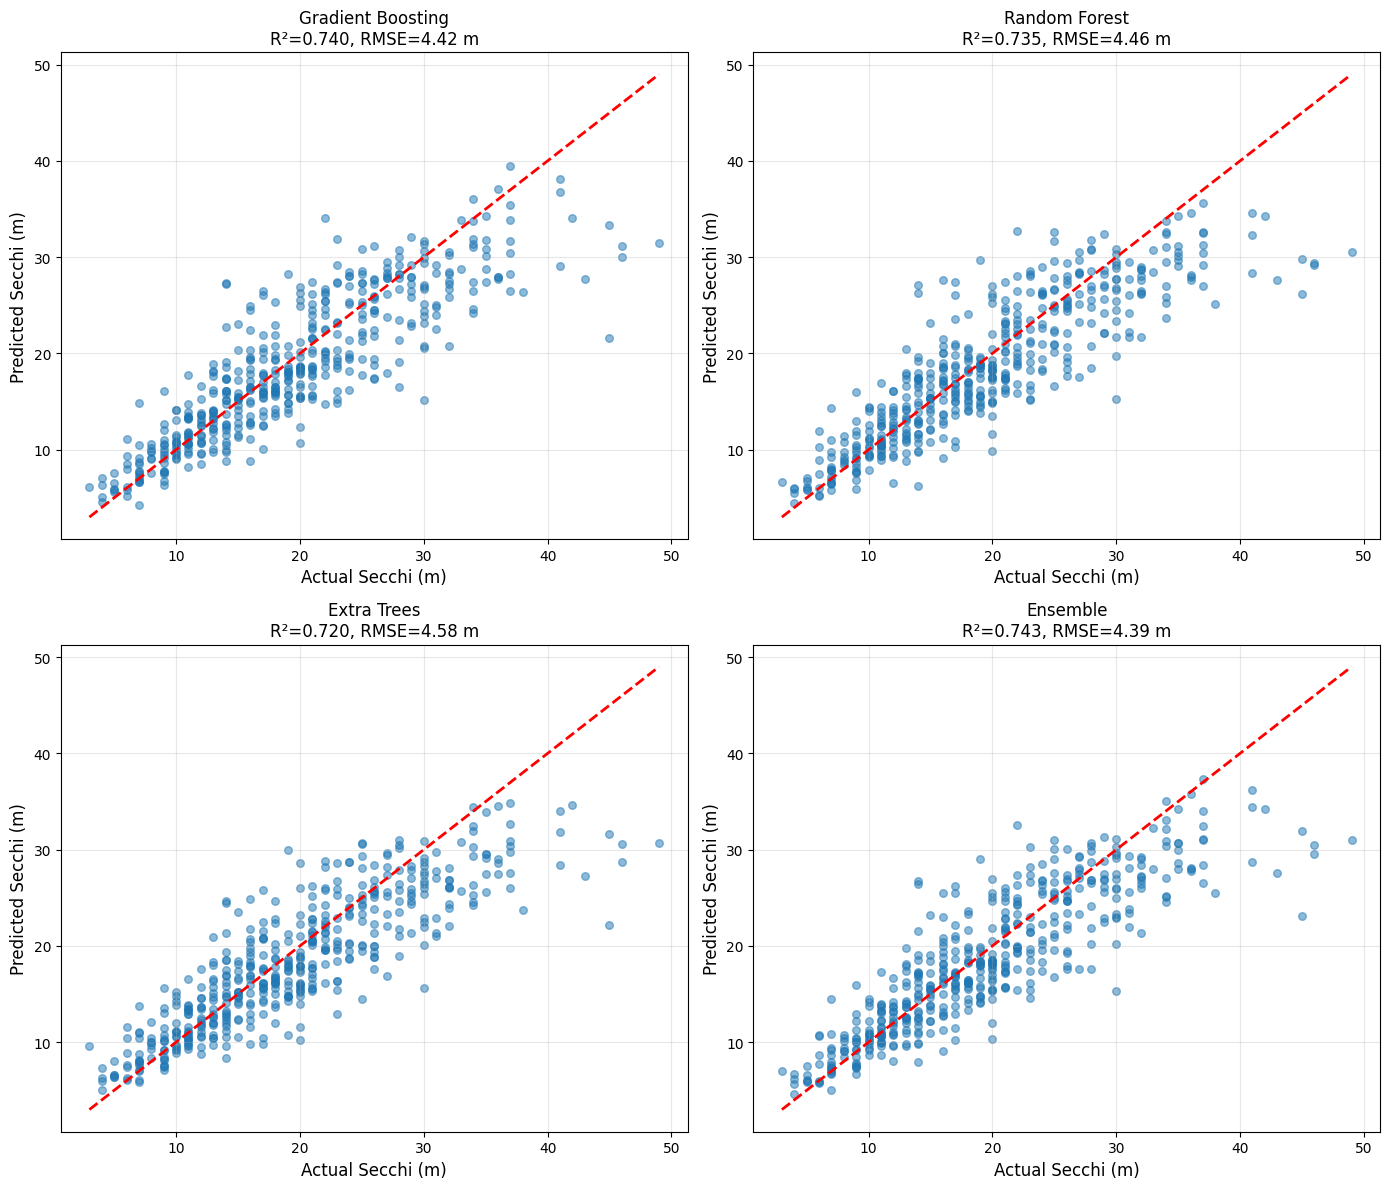

Saved: ../results/feature_importance_specific.png


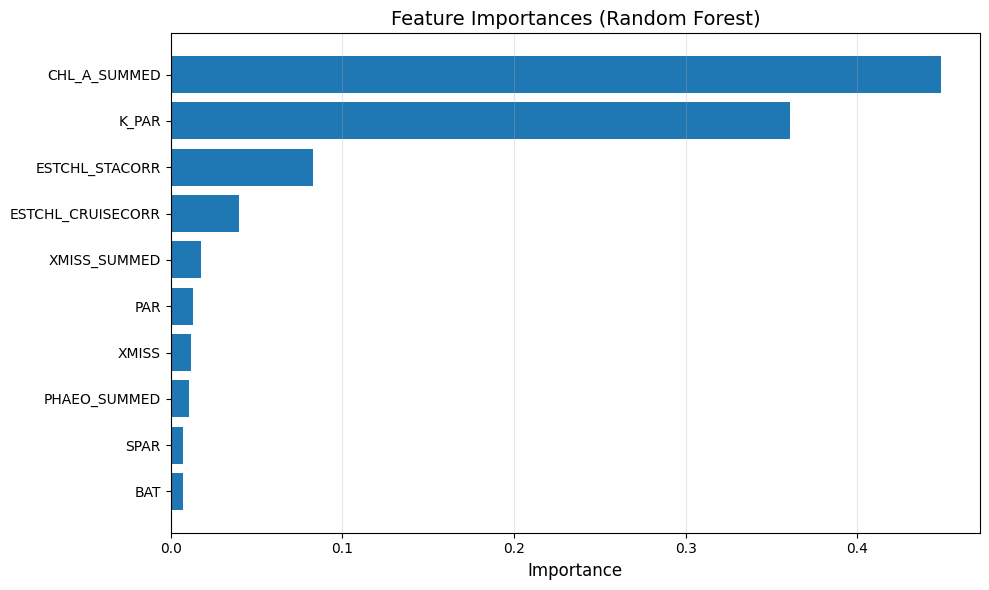

Saved: ../results/residual_plot_specific.png


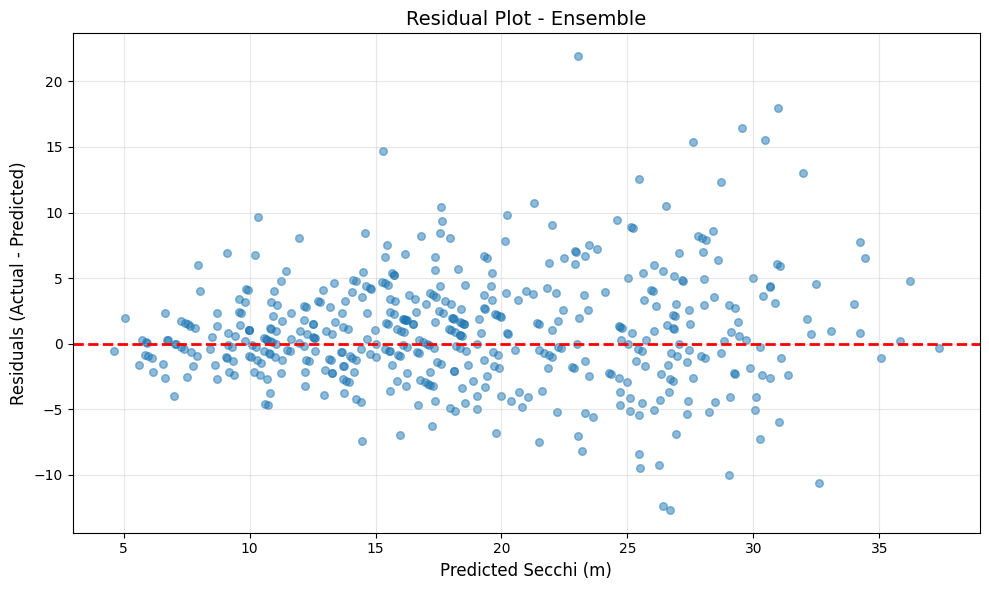

Saved: ../results/error_distribution_specific.png


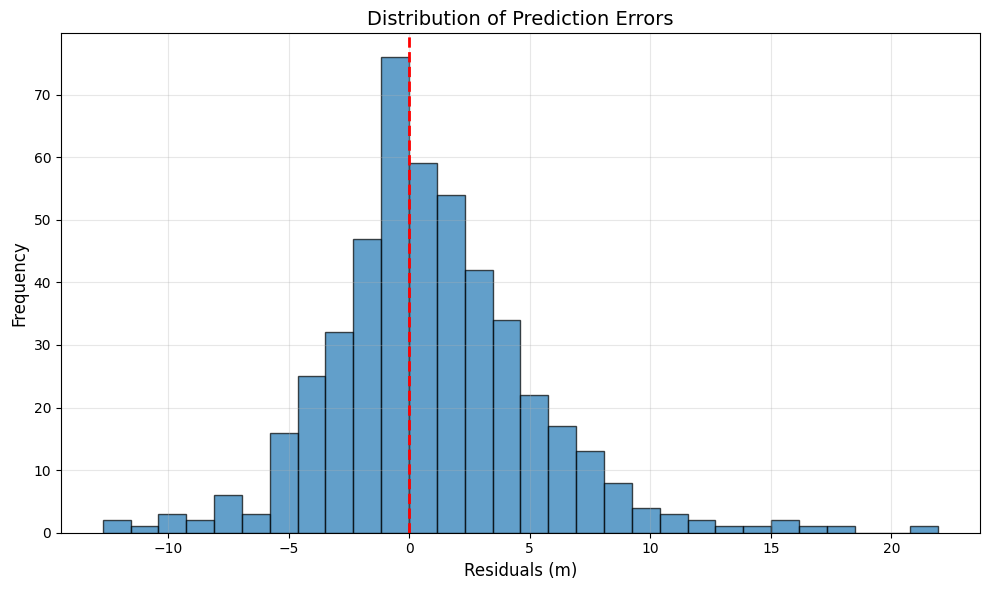


ANALYSIS COMPLETE!

Best Model: Ensemble (R² = 0.743)
Models saved to: ../Models
Results saved to: ../results


In [1]:
# ============================================================================
# IMPROVED SECCHI PREDICTION MODEL - SPECIFIC FEATURES ONLY
# ============================================================================

import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor, ExtraTreesRegressor
from sklearn.preprocessing import RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import joblib

# ============================================================================
# 1. LOAD DATA
# ============================================================================

CACHE_DIR = Path('../Data/Parquet')
CACHE_DIR.mkdir(exist_ok=True)

def load_or_cache(csv_path, parquet_path, usecols=None):
    parquet_path = Path(parquet_path)
    
    if parquet_path.exists():
        print(f"Loading cached: {parquet_path}")
        return pd.read_parquet(parquet_path)
    
    print(f"Reading CSV: {csv_path}")
    df = pd.read_csv(csv_path, usecols=usecols, low_memory=False)
    
    obj_cols = df.select_dtypes(include="object").columns
    if len(obj_cols) > 0:
        df[obj_cols] = df[obj_cols].astype("string")
    
    print(f"Caching → {parquet_path}")
    df.to_parquet(parquet_path)
    
    return df

enhanced_df = load_or_cache(
    '../Data/Enhanced.csv',
    CACHE_DIR / 'Enhanced.parquet'
)

print(f"Original dataset shape: {enhanced_df.shape}")

# Convert all columns to numeric
for col in enhanced_df.columns:
    enhanced_df[col] = pd.to_numeric(enhanced_df[col], errors='coerce')

# ============================================================================
# 2. PREPARE DATA WITH SPECIFIC FEATURES ONLY
# ============================================================================

print("\n" + "="*80)
print("DATA PREPARATION")
print("="*80)

df = enhanced_df.copy()

# Define target
target_col = "Secchi"

# Define ONLY the specific features you want
feature_cols = [
    'ESTCHL_CRUISECORR',
    'ESTCHL_STACORR',
    'BAT',
    'XMISS',
    'SPAR',
    'PAR',
    'XMISS_SUMMED',
    'CHL_A_SUMMED',
    'PHAEO_SUMMED',
    'K_PAR'
]

print(f"\nNumber of features: {len(feature_cols)}")
print(f"Features: {feature_cols}")

# Check which features exist in the dataset
missing_features = [col for col in feature_cols if col not in df.columns]
if missing_features:
    print(f"\nWARNING: These features are missing from the dataset: {missing_features}")
    feature_cols = [col for col in feature_cols if col in df.columns]
    print(f"Using {len(feature_cols)} available features: {feature_cols}")

# Prepare X and y
X = df[feature_cols].copy()
y = df[target_col].copy()

# Only remove rows where TARGET is missing or invalid
mask = (y > 0) & y.notna()
X = X[mask]
y = y[mask]

print(f"\nSample size after removing invalid TARGET values: {len(X)}")

# Check NaN count per feature
nan_counts = X.isna().sum()
print(f"\nNaN counts per feature:")
for feat in feature_cols:
    if feat in nan_counts.index:
        print(f"  {feat}: {nan_counts[feat]} ({nan_counts[feat]/len(X)*100:.1f}%)")

# Log-transform target
y_log = np.log(y)

# ============================================================================
# 3. TRAIN/TEST SPLIT (BEFORE IMPUTATION)
# ============================================================================

X_train, X_test, y_train_log, y_test_log = train_test_split(
    X, y_log,
    test_size=0.2,
    random_state=42
)

print(f"\nTraining set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")

# ============================================================================
# 4. IMPUTATION (Handle Missing Values)
# ============================================================================

print("\n" + "="*80)
print("IMPUTING MISSING VALUES")
print("="*80)

# Use median imputation
imputer = SimpleImputer(strategy='median')
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

# Convert back to DataFrame
X_train = pd.DataFrame(X_train_imputed, columns=X_train.columns, index=X_train.index)
X_test = pd.DataFrame(X_test_imputed, columns=X_test.columns, index=X_test.index)

print(f"Imputation complete")
print(f"Training set NaN count: {X_train.isna().sum().sum()}")
print(f"Test set NaN count: {X_test.isna().sum().sum()}")

# ============================================================================
# 5. FEATURE SCALING
# ============================================================================

print("\n" + "="*80)
print("FEATURE SCALING")
print("="*80)

scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame
X_train_final = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_final = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print("Scaling complete with RobustScaler")

# ============================================================================
# 6. TRAIN GRADIENT BOOSTING MODEL
# ============================================================================

print("\n" + "="*80)
print("TRAINING GRADIENT BOOSTING MODEL")
print("="*80)

hgb = HistGradientBoostingRegressor(random_state=42)

param_grid = {
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [5, 10, 15, None],
    "max_iter": [300, 500, 800],
    "min_samples_leaf": [10, 20, 50],
    "l2_regularization": [0, 0.01, 0.1]
}

print("\nStarting GridSearchCV (this may take a while)...")

grid_search = GridSearchCV(
    hgb,
    param_grid,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_final, y_train_log)

best_hgb = grid_search.best_estimator_

print("\nBest Parameters:")
for param, value in grid_search.best_params_.items():
    print(f"  {param}: {value}")

# ============================================================================
# 7. TRAIN ENSEMBLE MODELS
# ============================================================================

print("\n" + "="*80)
print("TRAINING ENSEMBLE MODELS")
print("="*80)

# Random Forest
rf = RandomForestRegressor(
    n_estimators=200, 
    max_depth=15,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1
)
print("Training Random Forest...")
rf.fit(X_train_final, y_train_log)

# Extra Trees
et = ExtraTreesRegressor(
    n_estimators=200,
    max_depth=15,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1
)
print("Training Extra Trees...")
et.fit(X_train_final, y_train_log)

# ============================================================================
# 8. PREDICTIONS
# ============================================================================

print("\n" + "="*80)
print("MAKING PREDICTIONS")
print("="*80)

# Individual model predictions (log scale)
y_pred_hgb_log = best_hgb.predict(X_test_final)
y_pred_rf_log = rf.predict(X_test_final)
y_pred_et_log = et.predict(X_test_final)

# Back-transform to original scale
y_pred_hgb = np.exp(y_pred_hgb_log)
y_pred_rf = np.exp(y_pred_rf_log)
y_pred_et = np.exp(y_pred_et_log)
y_test = np.exp(y_test_log)

# Ensemble prediction (weighted average)
y_pred_ensemble = (0.5 * y_pred_hgb + 0.3 * y_pred_rf + 0.2 * y_pred_et)

# ============================================================================
# 9. EVALUATION
# ============================================================================

print("\n" + "="*80)
print("MODEL EVALUATION")
print("="*80)

models_results = {
    'Gradient Boosting': y_pred_hgb,
    'Random Forest': y_pred_rf,
    'Extra Trees': y_pred_et,
    'Ensemble': y_pred_ensemble
}

best_r2 = -np.inf
best_model_name = None

for model_name, y_pred in models_results.items():
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    if r2 > best_r2:
        best_r2 = r2
        best_model_name = model_name
    
    print(f"\n{model_name}:")
    print(f"  RMSE: {rmse:.3f} m")
    print(f"  MAE:  {mae:.3f} m")
    print(f"  R²:   {r2:.3f}")

print(f"\n{'='*80}")
print(f"BEST MODEL: {best_model_name} (R² = {best_r2:.3f})")
print(f"{'='*80}")

# ============================================================================
# 10. FEATURE IMPORTANCE
# ============================================================================

print("\n" + "="*80)
print("FEATURE IMPORTANCE")
print("="*80)

feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print("\nFeature Importances (from Random Forest):")
print(feature_importance.to_string(index=False))

# ============================================================================
# 11. SAVE MODELS
# ============================================================================

print("\n" + "="*80)
print("SAVING MODELS")
print("="*80)

models_dir = Path("../Models")
models_dir.mkdir(exist_ok=True)

# Save models
joblib.dump(best_hgb, models_dir / "GradientBoost_specific_features.pkl")
joblib.dump(rf, models_dir / "RandomForest_specific_features.pkl")
joblib.dump(et, models_dir / "ExtraTrees_specific_features.pkl")
joblib.dump(scaler, models_dir / "scaler_specific_features.pkl")
joblib.dump(imputer, models_dir / "imputer_specific_features.pkl")

# Save feature list
pd.DataFrame({'features': feature_cols}).to_csv(models_dir / "selected_features.csv", index=False)

# Save feature importance
feature_importance.to_csv(models_dir / "feature_importance.csv", index=False)

print(f"\nAll models saved to {models_dir}")

# ============================================================================
# 12. VISUALIZATIONS
# ============================================================================

print("\n" + "="*80)
print("CREATING VISUALIZATIONS")
print("="*80)

results_dir = Path("../results")
results_dir.mkdir(exist_ok=True)

# Figure 1: Actual vs Predicted (all models)
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for idx, (model_name, y_pred) in enumerate(models_results.items()):
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    axes[idx].scatter(y_test, y_pred, alpha=0.5, s=30)
    
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    
    axes[idx].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)
    axes[idx].set_xlabel("Actual Secchi (m)", fontsize=12)
    axes[idx].set_ylabel("Predicted Secchi (m)", fontsize=12)
    axes[idx].set_title(f"{model_name}\nR²={r2:.3f}, RMSE={rmse:.2f} m", fontsize=12)
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(results_dir / "model_comparison_specific_features.png", dpi=300, bbox_inches='tight')
print(f"Saved: {results_dir / 'model_comparison_specific_features.png'}")
plt.show()

# Figure 2: Feature Importance
plt.figure(figsize=(10, 6))
plt.barh(range(len(feature_importance)), feature_importance['importance'])
plt.yticks(range(len(feature_importance)), feature_importance['feature'])
plt.xlabel('Importance', fontsize=12)
plt.title('Feature Importances (Random Forest)', fontsize=14)
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig(results_dir / "feature_importance_specific.png", dpi=300, bbox_inches='tight')
print(f"Saved: {results_dir / 'feature_importance_specific.png'}")
plt.show()

# Figure 3: Residual Plot (Best Model)
best_pred = models_results[best_model_name]
residuals = y_test - best_pred

plt.figure(figsize=(10, 6))
plt.scatter(best_pred, residuals, alpha=0.5, s=30)
plt.axhline(0, color='red', linestyle='--', lw=2)
plt.xlabel("Predicted Secchi (m)", fontsize=12)
plt.ylabel("Residuals (Actual - Predicted)", fontsize=12)
plt.title(f"Residual Plot - {best_model_name}", fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(results_dir / "residual_plot_specific.png", dpi=300, bbox_inches='tight')
print(f"Saved: {results_dir / 'residual_plot_specific.png'}")
plt.show()

# Figure 4: Error Distribution
plt.figure(figsize=(10, 6))
plt.hist(residuals, bins=30, edgecolor='black', alpha=0.7)
plt.axvline(0, color='red', linestyle='--', lw=2)
plt.xlabel("Residuals (m)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.title("Distribution of Prediction Errors", fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(results_dir / "error_distribution_specific.png", dpi=300, bbox_inches='tight')
print(f"Saved: {results_dir / 'error_distribution_specific.png'}")
plt.show()

print("\n" + "="*80)
print("ANALYSIS COMPLETE!")
print("="*80)
print(f"\nBest Model: {best_model_name} (R² = {best_r2:.3f})")
print(f"Models saved to: {models_dir}")
print(f"Results saved to: {results_dir}")

Loading cached: ../Data/Parquet/New_estchlsummed.parquet
Original dataset shape: (1971, 43)

DATA PREPARATION

Number of features: 3
Features: ['ESTCHL_SUMMED', 'K_PAR', 'XMISS_SUMMED']

Sample size after removing invalid TARGET values: 1971

NaN counts per feature:
  ESTCHL_SUMMED: 0 (0.0%)
  K_PAR: 0 (0.0%)
  XMISS_SUMMED: 0 (0.0%)

Training set size: 1576
Test set size: 395

IMPUTING MISSING VALUES
Imputation complete
Training set NaN count: 0
Test set NaN count: 0

FEATURE SCALING
Scaling complete with RobustScaler

TRAINING GRADIENT BOOSTING MODEL

Starting GridSearchCV (this may take a while)...
Fitting 5 folds for each of 324 candidates, totalling 1620 fits

Best Parameters:
  l2_regularization: 0.01
  learning_rate: 0.01
  max_depth: 5
  max_iter: 800
  min_samples_leaf: 50

TRAINING ENSEMBLE MODELS
Training Random Forest...
Training Extra Trees...

MAKING PREDICTIONS

MODEL EVALUATION

Gradient Boosting:
  RMSE: 4.570 m
  MAE:  3.380 m
  R²:   0.731

Random Forest:
  RMSE: 4.5

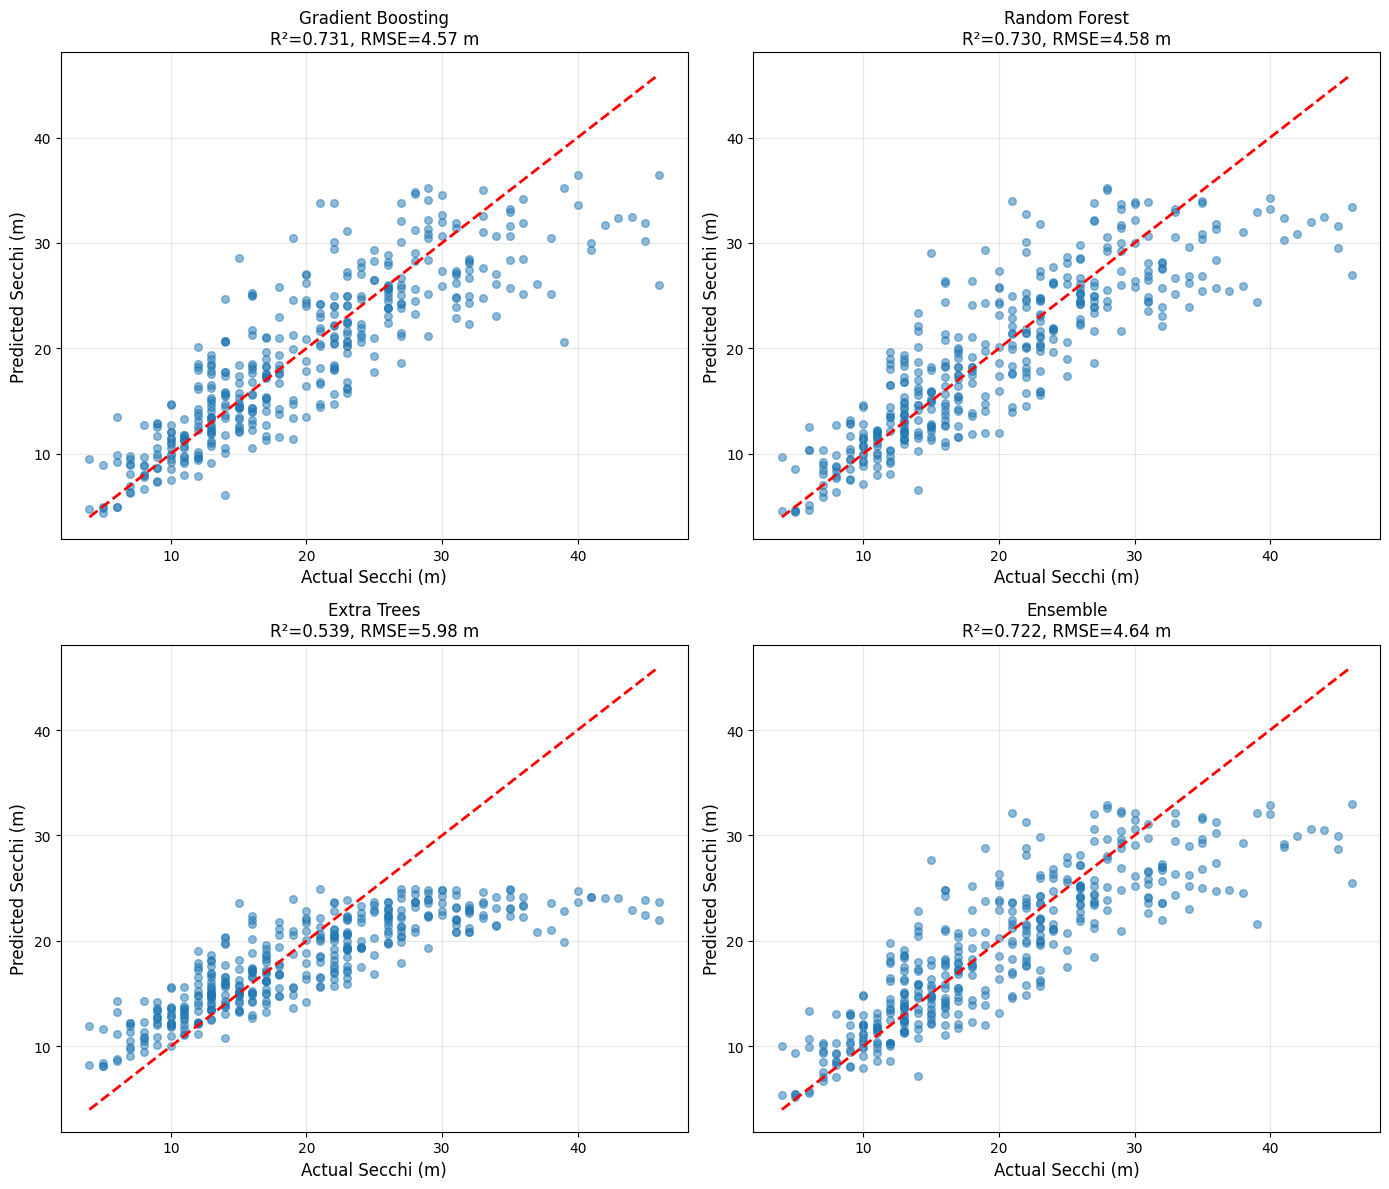

Saved: ../results/feature_importance_specific.png


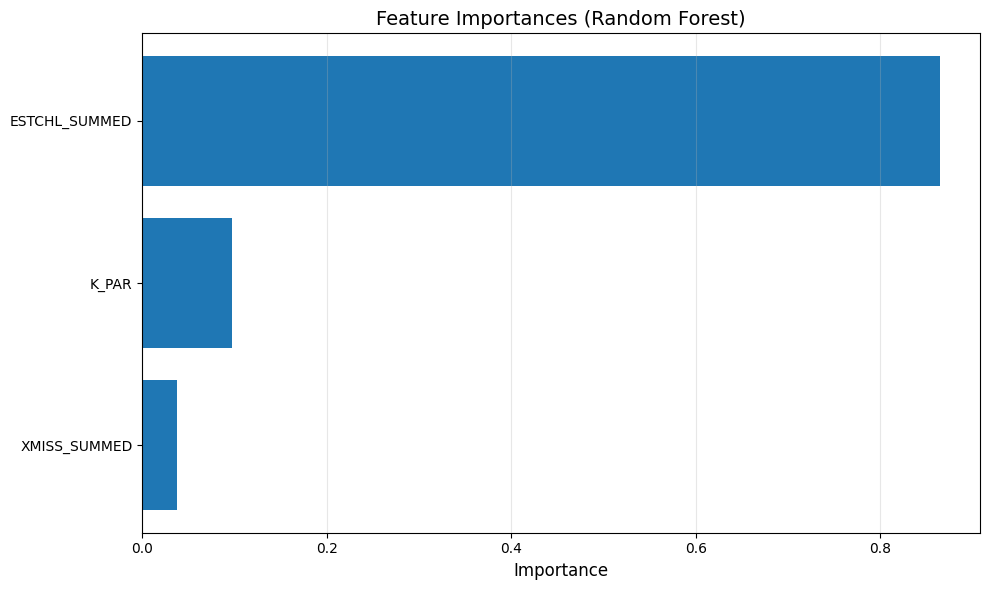

Saved: ../results/residual_plot_specific.png


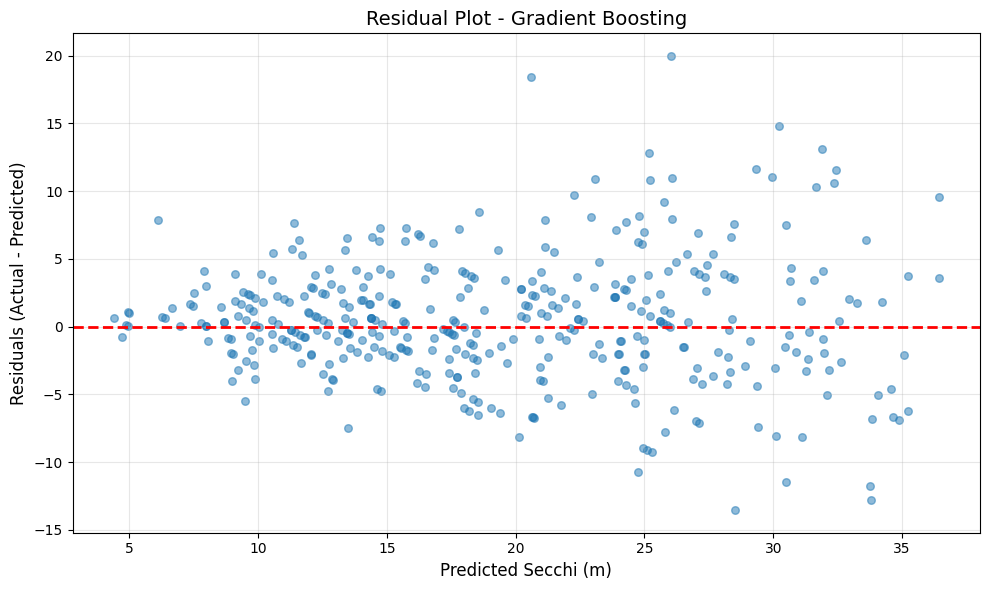

Saved: ../results/error_distribution_specific.png


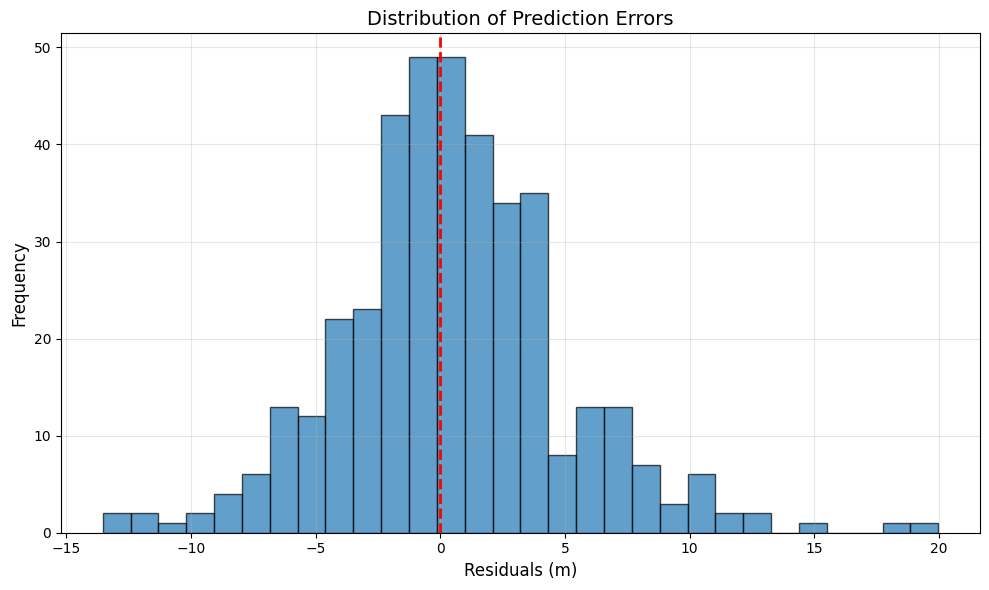


ANALYSIS COMPLETE!

Best Model: Gradient Boosting (R² = 0.731)
Models saved to: ../Models
Results saved to: ../results


In [2]:
# ============================================================================
# IMPROVED SECCHI PREDICTION MODEL - SPECIFIC FEATURES ONLY
# ============================================================================

import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor, ExtraTreesRegressor
from sklearn.preprocessing import RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import joblib

# ============================================================================
# 1. LOAD DATA
# ============================================================================

CACHE_DIR = Path('../Data/Parquet')
CACHE_DIR.mkdir(exist_ok=True)

def load_or_cache(csv_path, parquet_path, usecols=None):
    parquet_path = Path(parquet_path)
    
    if parquet_path.exists():
        print(f"Loading cached: {parquet_path}")
        return pd.read_parquet(parquet_path)
    
    print(f"Reading CSV: {csv_path}")
    df = pd.read_csv(csv_path, usecols=usecols, low_memory=False)
    
    obj_cols = df.select_dtypes(include="object").columns
    if len(obj_cols) > 0:
        df[obj_cols] = df[obj_cols].astype("string")
    
    print(f"Caching → {parquet_path}")
    df.to_parquet(parquet_path)
    
    return df

enhanced_df = load_or_cache(
    '../Data/Enhanced.csv',
    CACHE_DIR / 'New_estchlsummed.parquet'
)

print(f"Original dataset shape: {enhanced_df.shape}")

# Convert all columns to numeric
for col in enhanced_df.columns:
    enhanced_df[col] = pd.to_numeric(enhanced_df[col], errors='coerce')

# ============================================================================
# 2. PREPARE DATA WITH SPECIFIC FEATURES ONLY
# ============================================================================

print("\n" + "="*80)
print("DATA PREPARATION")
print("="*80)

df = enhanced_df.copy()

# Define target
target_col = "Secchi"

# Define ONLY the specific features you want
feature_cols = [
    'ESTCHL_SUMMED',
    'K_PAR',
    'XMISS_SUMMED',
]

print(f"\nNumber of features: {len(feature_cols)}")
print(f"Features: {feature_cols}")

# Check which features exist in the dataset
missing_features = [col for col in feature_cols if col not in df.columns]
if missing_features:
    print(f"\nWARNING: These features are missing from the dataset: {missing_features}")
    feature_cols = [col for col in feature_cols if col in df.columns]
    print(f"Using {len(feature_cols)} available features: {feature_cols}")

# Prepare X and y
X = df[feature_cols].copy()
y = df[target_col].copy()

# Only remove rows where TARGET is missing or invalid
mask = (y > 0) & y.notna()
X = X[mask]
y = y[mask]

print(f"\nSample size after removing invalid TARGET values: {len(X)}")

# Check NaN count per feature
nan_counts = X.isna().sum()
print(f"\nNaN counts per feature:")
for feat in feature_cols:
    if feat in nan_counts.index:
        print(f"  {feat}: {nan_counts[feat]} ({nan_counts[feat]/len(X)*100:.1f}%)")

# Log-transform target
y_log = np.log(y)

# ============================================================================
# 3. TRAIN/TEST SPLIT (BEFORE IMPUTATION)
# ============================================================================

X_train, X_test, y_train_log, y_test_log = train_test_split(
    X, y_log,
    test_size=0.2,
    random_state=42
)

print(f"\nTraining set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")

# ============================================================================
# 4. IMPUTATION (Handle Missing Values)
# ============================================================================

print("\n" + "="*80)
print("IMPUTING MISSING VALUES")
print("="*80)

# Use median imputation
imputer = SimpleImputer(strategy='median')
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

# Convert back to DataFrame
X_train = pd.DataFrame(X_train_imputed, columns=X_train.columns, index=X_train.index)
X_test = pd.DataFrame(X_test_imputed, columns=X_test.columns, index=X_test.index)

print(f"Imputation complete")
print(f"Training set NaN count: {X_train.isna().sum().sum()}")
print(f"Test set NaN count: {X_test.isna().sum().sum()}")

# ============================================================================
# 5. FEATURE SCALING
# ============================================================================

print("\n" + "="*80)
print("FEATURE SCALING")
print("="*80)

scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame
X_train_final = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_final = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print("Scaling complete with RobustScaler")

# ============================================================================
# 6. TRAIN GRADIENT BOOSTING MODEL
# ============================================================================

print("\n" + "="*80)
print("TRAINING GRADIENT BOOSTING MODEL")
print("="*80)

hgb = HistGradientBoostingRegressor(random_state=42)

param_grid = {
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [5, 10, 15, None],
    "max_iter": [300, 500, 800],
    "min_samples_leaf": [10, 20, 50],
    "l2_regularization": [0, 0.01, 0.1]
}

print("\nStarting GridSearchCV (this may take a while)...")

grid_search = GridSearchCV(
    hgb,
    param_grid,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_final, y_train_log)

best_hgb = grid_search.best_estimator_

print("\nBest Parameters:")
for param, value in grid_search.best_params_.items():
    print(f"  {param}: {value}")

# ============================================================================
# 7. TRAIN ENSEMBLE MODELS
# ============================================================================

print("\n" + "="*80)
print("TRAINING ENSEMBLE MODELS")
print("="*80)

# Random Forest
rf = RandomForestRegressor(
    n_estimators=200, 
    max_depth=15,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1
)
print("Training Random Forest...")
rf.fit(X_train_final, y_train_log)

# Extra Trees
et = ExtraTreesRegressor(
    n_estimators=200,
    max_depth=15,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1
)
print("Training Extra Trees...")
et.fit(X_train_final, y_train_log)

# ============================================================================
# 8. PREDICTIONS
# ============================================================================

print("\n" + "="*80)
print("MAKING PREDICTIONS")
print("="*80)

# Individual model predictions (log scale)
y_pred_hgb_log = best_hgb.predict(X_test_final)
y_pred_rf_log = rf.predict(X_test_final)
y_pred_et_log = et.predict(X_test_final)

# Back-transform to original scale
y_pred_hgb = np.exp(y_pred_hgb_log)
y_pred_rf = np.exp(y_pred_rf_log)
y_pred_et = np.exp(y_pred_et_log)
y_test = np.exp(y_test_log)

# Ensemble prediction (weighted average)
y_pred_ensemble = (0.5 * y_pred_hgb + 0.3 * y_pred_rf + 0.2 * y_pred_et)

# ============================================================================
# 9. EVALUATION
# ============================================================================

print("\n" + "="*80)
print("MODEL EVALUATION")
print("="*80)

models_results = {
    'Gradient Boosting': y_pred_hgb,
    'Random Forest': y_pred_rf,
    'Extra Trees': y_pred_et,
    'Ensemble': y_pred_ensemble
}

best_r2 = -np.inf
best_model_name = None

for model_name, y_pred in models_results.items():
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    if r2 > best_r2:
        best_r2 = r2
        best_model_name = model_name
    
    print(f"\n{model_name}:")
    print(f"  RMSE: {rmse:.3f} m")
    print(f"  MAE:  {mae:.3f} m")
    print(f"  R²:   {r2:.3f}")

print(f"\n{'='*80}")
print(f"BEST MODEL: {best_model_name} (R² = {best_r2:.3f})")
print(f"{'='*80}")

# ============================================================================
# 10. FEATURE IMPORTANCE
# ============================================================================

print("\n" + "="*80)
print("FEATURE IMPORTANCE")
print("="*80)

feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print("\nFeature Importances (from Random Forest):")
print(feature_importance.to_string(index=False))

# ============================================================================
# 11. SAVE MODELS
# ============================================================================

print("\n" + "="*80)
print("SAVING MODELS")
print("="*80)

models_dir = Path("../Models")
models_dir.mkdir(exist_ok=True)

# Save models
joblib.dump(best_hgb, models_dir / "GradientBoost_specific_features.pkl")
joblib.dump(rf, models_dir / "RandomForest_specific_features.pkl")
joblib.dump(et, models_dir / "ExtraTrees_specific_features.pkl")
joblib.dump(scaler, models_dir / "scaler_specific_features.pkl")
joblib.dump(imputer, models_dir / "imputer_specific_features.pkl")

# Save feature list
pd.DataFrame({'features': feature_cols}).to_csv(models_dir / "selected_features.csv", index=False)

# Save feature importance
feature_importance.to_csv(models_dir / "feature_importance.csv", index=False)

print(f"\nAll models saved to {models_dir}")

# ============================================================================
# 12. VISUALIZATIONS
# ============================================================================

print("\n" + "="*80)
print("CREATING VISUALIZATIONS")
print("="*80)

results_dir = Path("../results")
results_dir.mkdir(exist_ok=True)

# Figure 1: Actual vs Predicted (all models)
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for idx, (model_name, y_pred) in enumerate(models_results.items()):
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    axes[idx].scatter(y_test, y_pred, alpha=0.5, s=30)
    
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    
    axes[idx].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)
    axes[idx].set_xlabel("Actual Secchi (m)", fontsize=12)
    axes[idx].set_ylabel("Predicted Secchi (m)", fontsize=12)
    axes[idx].set_title(f"{model_name}\nR²={r2:.3f}, RMSE={rmse:.2f} m", fontsize=12)
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(results_dir / "model_comparison_specific_features.png", dpi=300, bbox_inches='tight')
print(f"Saved: {results_dir / 'model_comparison_specific_features.png'}")
plt.show()

# Figure 2: Feature Importance
plt.figure(figsize=(10, 6))
plt.barh(range(len(feature_importance)), feature_importance['importance'])
plt.yticks(range(len(feature_importance)), feature_importance['feature'])
plt.xlabel('Importance', fontsize=12)
plt.title('Feature Importances (Random Forest)', fontsize=14)
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig(results_dir / "feature_importance_specific.png", dpi=300, bbox_inches='tight')
print(f"Saved: {results_dir / 'feature_importance_specific.png'}")
plt.show()

# Figure 3: Residual Plot (Best Model)
best_pred = models_results[best_model_name]
residuals = y_test - best_pred

plt.figure(figsize=(10, 6))
plt.scatter(best_pred, residuals, alpha=0.5, s=30)
plt.axhline(0, color='red', linestyle='--', lw=2)
plt.xlabel("Predicted Secchi (m)", fontsize=12)
plt.ylabel("Residuals (Actual - Predicted)", fontsize=12)
plt.title(f"Residual Plot - {best_model_name}", fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(results_dir / "residual_plot_specific.png", dpi=300, bbox_inches='tight')
print(f"Saved: {results_dir / 'residual_plot_specific.png'}")
plt.show()

# Figure 4: Error Distribution
plt.figure(figsize=(10, 6))
plt.hist(residuals, bins=30, edgecolor='black', alpha=0.7)
plt.axvline(0, color='red', linestyle='--', lw=2)
plt.xlabel("Residuals (m)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.title("Distribution of Prediction Errors", fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(results_dir / "error_distribution_specific.png", dpi=300, bbox_inches='tight')
print(f"Saved: {results_dir / 'error_distribution_specific.png'}")
plt.show()

print("\n" + "="*80)
print("ANALYSIS COMPLETE!")
print("="*80)
print(f"\nBest Model: {best_model_name} (R² = {best_r2:.3f})")
print(f"Models saved to: {models_dir}")
print(f"Results saved to: {results_dir}")